# Modelling

## Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scripts.hourly_forecasting.data_preparation.data_pipeline import prepare_data_forecasting
from scripts.hourly_forecasting.data_preparation.feature_engineering import construct_features, discard_features
from scripts.hourly_forecasting.models.models import NaiveSimilarDay

## Load and process data

In [3]:
data_path = "../../../data/Hourly_Electricity_Demand_Gen_Weather_Spain/{}.csv";

energy_data_path = data_path.format("energy_dataset");
weather_data_path = data_path.format("weather_features");

energy_data = pd.read_csv(energy_data_path);
weather_data = pd.read_csv(weather_data_path);

data = prepare_data_forecasting(energy_data, weather_data);
data = construct_features(data);
data = discard_features(data);

In [4]:
pd.set_option("display.max_columns", 100);

## Benchmarks

### Naive similar day modelling

In [5]:
data.iloc[int(np.round(data.shape[0] * 0.7)):].shape[0] / data.shape[0] * 100

29.99942961441935

In [6]:
NaiveSimilarDay.initial_data_point(data)

Timestamp('2015-01-12 00:00:00+0000', tz='UTC')

In [7]:
naive_model = NaiveSimilarDay(data.ffill());
naive_model.forecast("2015-01-12")

2015-01-12 00:00:00+00:00    64.89
2015-01-12 01:00:00+00:00    60.91
2015-01-12 02:00:00+00:00    59.68
2015-01-12 03:00:00+00:00    58.04
2015-01-12 04:00:00+00:00    59.57
                             ...  
2018-12-31 18:00:00+00:00    75.30
2018-12-31 19:00:00+00:00    74.95
2018-12-31 20:00:00+00:00    73.16
2018-12-31 21:00:00+00:00    70.39
2018-12-31 22:00:00+00:00    70.20
Name: price actual, Length: 34799, dtype: float64

In [8]:
NaiveSimilarDay.initial_data_point(data.iloc[int(np.round(data.shape[0] * 0.7)):])

Timestamp('2017-10-30 00:00:00+0000', tz='UTC')

In [9]:
naive_model = NaiveSimilarDay(data.ffill().iloc[int(np.round(data.shape[0] * 0.7)):]);
forecasts = naive_model.forecast("2017-10-30");

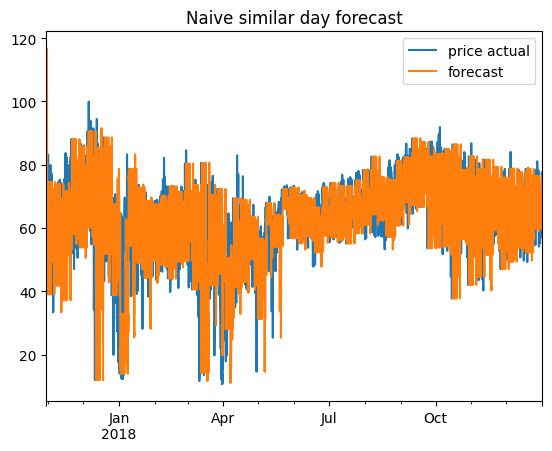

In [10]:
pd.concat([data["price actual"].loc["2017-10-30":], forecasts.rename("forecast")], axis=1).plot(kind="line", title="Naive similar day forecast");

In [15]:
benchmark_mse = mean_squared_error(data["price actual"].loc["2017-10-30":], forecasts);
benchmark_mae = mean_absolute_error(data["price actual"].loc["2017-10-30":], forecasts);

print("MSE: {:.3f} €/MWh**2".format(benchmark_mse));
print("RMSE: {:.3f} €/MWh".format(np.sqrt(benchmark_mse)));
print("MAE: {:.3f} €/MWh".format(benchmark_mae));

MSE: 93.596 €/MWh**2
RMSE: 9.675 €/MWh
MAE: 6.190 €/MWh


## SARIMA modelling

## Deep Learning time series modelling